# N1 · 2D 扩散: 看见去噪轨迹 (2D Diffusion)

> 配套 13.1-L2/L3 · 在 2D 双月分布上跑 DDPM: 可视化前向加噪 + 训练去噪网络 + **去噪轨迹**
> (点云从纯噪声逐步收敛成双月)。亲眼看见「生成 = 从噪声去噪」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np
import diffusion as df
print('diffusion 就绪')

diffusion 就绪


## 1. 目标分布: 2D 双月 (扩散要学会生成它)

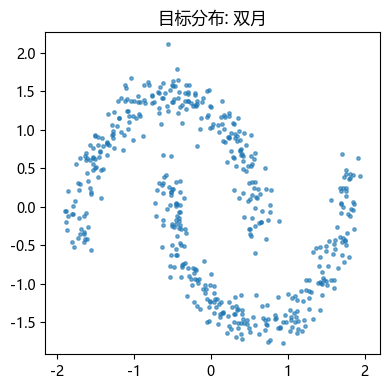

In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
x0 = df.make_two_moons(n=512, seed=1)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(x0[:,0], x0[:,1], s=6, alpha=0.6); ax.set_title('目标分布: 双月'); ax.axis('equal')
plt.tight_layout(); plt.show()

## 2. 前向加噪 (L2): 双月 → 逐步糊掉 → 纯噪声 (闭式, 不同 t 一步算)

C:\Users\ericp\AppData\Local\Temp\ipykernel_81260\320787097.py:14: UserWarning: Glyph 8113 (\N{GREEK SMALL LETTER ALPHA WITH MACRON}) missing from font(s) Microsoft YaHei.
  plt.suptitle('前向加噪: 双月逐步变成纯噪声'); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8113 (\N{GREEK SMALL LETTER ALPHA WITH MACRON}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


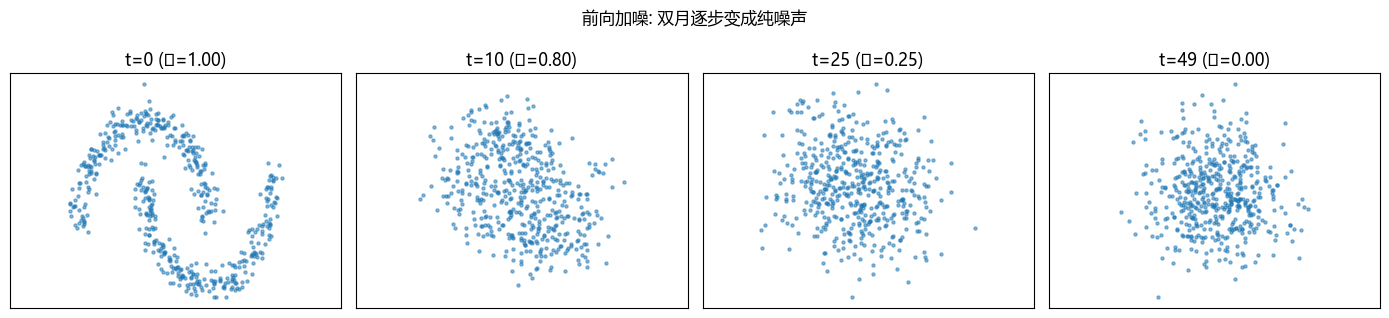

→ t 越大, 形状越糊, 最后变成一团高斯噪声 (生成的起点)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
betas, alphas, abars = df.make_beta_schedule(T=50)
rng = np.random.default_rng(0)
ts = [0, 10, 25, 49]
fig, axes = plt.subplots(1, len(ts), figsize=(14,3.2))
for ax, t in zip(axes, ts):
    xt, _ = df.forward_noise(x0, t, abars, rng)
    ax.scatter(xt[:,0], xt[:,1], s=5, alpha=0.5)
    ax.set_title(f't={t} (ᾱ={abars[t]:.2f})'); ax.axis('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('前向加噪: 双月逐步变成纯噪声'); plt.tight_layout(); plt.show()
print('→ t 越大, 形状越糊, 最后变成一团高斯噪声 (生成的起点)。')

## 3. 训练去噪网络 (L3): 预测噪声的 MSE 回归

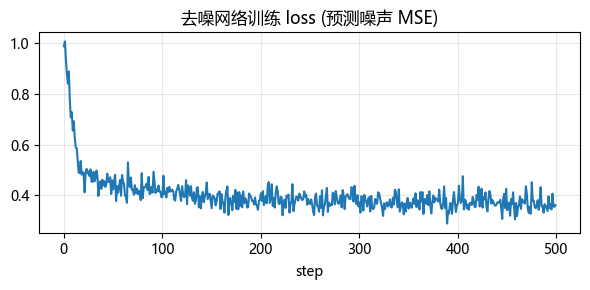

loss 0.989 → 0.361 (网络学会了预测噪声 = 估计 score)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import torch
torch.manual_seed(0)
model = df.build_denoiser()
losses, sched = df.train_diffusion(model, x0, T=50, epochs=500)
plt.figure(figsize=(6,3)); plt.plot(losses); plt.title('去噪网络训练 loss (预测噪声 MSE)')
plt.xlabel('step'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"loss {losses[0]:.3f} → {losses[-1]:.3f} (网络学会了预测噪声 = 估计 score)")

## 4. 去噪轨迹 (L3): 从纯噪声反向去噪, 看双月浮现 ⭐

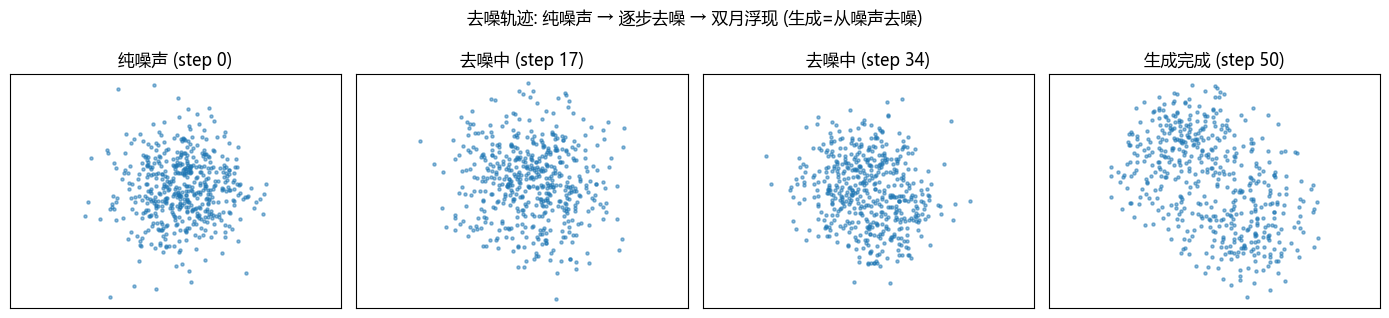

目标 std [1. 1.] vs 生成 std [0.96 0.99] (分布还原)
→ 这就是扩散: 从纯噪声出发, 沿网络的去噪指引 (score), 走回数据分布。


In [5]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
gen, traj = df.sample(model, sched, n=512, seed=3, record_traj=True)
snaps = [0, len(traj)//3, 2*len(traj)//3, len(traj)-1]
fig, axes = plt.subplots(1, len(snaps), figsize=(14,3.2))
for ax, k in zip(axes, snaps):
    ax.scatter(traj[k][:,0], traj[k][:,1], s=5, alpha=0.5)
    step = '纯噪声' if k==0 else ('生成完成' if k==len(traj)-1 else f'去噪中')
    ax.set_title(f'{step} (step {k})'); ax.axis('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('去噪轨迹: 纯噪声 → 逐步去噪 → 双月浮现 (生成=从噪声去噪)'); plt.tight_layout(); plt.show()
print(f"目标 std {x0.std(0).round(2)} vs 生成 std {gen.std(0).round(2)} (分布还原)")
print("→ 这就是扩散: 从纯噪声出发, 沿网络的去噪指引 (score), 走回数据分布。")

## 5. 反思
你**看见**了扩散在干什么: 前向把双月加噪成噪声, 反向从噪声去噪还原双月。带走:
- 扩散 = 前向加噪 (固定闭式) + 学反向去噪 (预测噪声 = 估计 score) + 采样 (反向走回数据)。
- 训练就是个 MSE 回归 (无 GAN/变分), 简洁是 DDPM 普及的关键。
- 高维图像/视频/动作只是同一机制在更高维 (N2 + M13 后续 + M11)。
下一步 N2: 把扩散扩到 tiny 图, 对比采样步数的质量权衡 (L4)。